# Movable 2–3 lens group: Optiland ray tracing + xrt material bridge

This notebook builds a configurable visible-light lens group and demonstrates how translating lenses changes convergence.

- **Optiland** is the authoritative thick-lens, multi-wavelength ray tracer.
- A transparent **paraxial ray model** makes position sweeps and interactive updates fast and provides an independent first-order check.
- **xrt** is used through its externally specified refractive-index material interface. This is deliberate: xrt's native refractive lens elements are primarily compound refractive X-ray lenses, whereas Optiland directly represents ordinary spherical glass lenses.

Edit `CFG` and `BASE_LENSES`. Keep two entries for a doublet group or three for a triplet group. All lengths are in mm.

## 0. Installation

Run once in the desired Jupyter kernel and restart the kernel.

In [1]:
# %pip install -U optiland xrt numpy matplotlib pandas ipywidgets
# After installation: Kernel -> Restart, then Run All.

In [1]:
from dataclasses import dataclass, replace
from pathlib import Path
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optiland import optic
from optiland.analysis import SpotDiagram
import xrt.backends.raycing.materials as xrt_materials

plt.rcParams.update({'figure.figsize': (10, 5.5), 'axes.grid': True, 'font.size': 11})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
HC_EV_NM = 1239.8419843320026

for package in ('optiland', 'xrt', 'numpy', 'matplotlib'):
    try:
        print(f'{package:10s} {metadata.version(package)}')
    except metadata.PackageNotFoundError:
        print(f'{package:10s} version unavailable')

optiland   0.6.1
xrt        1.6.2
numpy      1.26.4
matplotlib 3.9.2


## 1. Fully editable lens prescription

`z_mm` is the front-vertex position relative to lens 1. The entries must be ordered and must not overlap. Radii follow the usual sequential sign convention. The `n_reference` value is used only by the paraxial/xrt bridge; Optiland loads the named glass catalogue and its wavelength dispersion.

In [2]:
@dataclass(frozen=True)
class LensSpec:
    name: str
    z_mm: float
    radius_front_mm: float
    radius_back_mm: float
    thickness_mm: float
    material: str
    n_reference: float

@dataclass(frozen=True)
class LensGroupConfig:
    wavelengths_nm: tuple = (486.1, 587.6, 656.3)
    primary_wavelength_nm: float = 587.6
    field_angles_deg: tuple = (0.0, 2.0)
    aperture_diameter_mm: float = 12.0
    sensor_z_mm: float = 80.0
    n_trace_rays: int = 512
    moved_lens_index: int = 1
    movement_mm: float = 10.0
    save_figures: bool = True

CFG = LensGroupConfig()
BASE_LENSES = (
    LensSpec('L1', 0.0,  100.0, -100.0, 5.0, 'N-BK7', 1.5168),
    LensSpec('L2', 45.0, 150.0, -150.0, 4.0, 'N-SF5', 1.6727),
    LensSpec('L3', 70.0, 120.0, -120.0, 5.0, 'N-BK7', 1.5168),
)

def validate_prescription(lenses, sensor_z):
    if len(lenses) not in (2, 3):
        raise ValueError('Use exactly 2 or 3 lenses.')
    if not np.isclose(lenses[0].z_mm, 0.0):
        raise ValueError('Set the first lens front vertex to z_mm=0.')
    for left, right in zip(lenses[:-1], lenses[1:]):
        if right.z_mm <= left.z_mm + left.thickness_mm:
            raise ValueError(f'{left.name} overlaps {right.name}.')
    if sensor_z <= lenses[-1].z_mm + lenses[-1].thickness_mm:
        raise ValueError('The sensor must lie after the final lens.')

validate_prescription(BASE_LENSES, CFG.sensor_z_mm)
MOVED_LENSES = tuple(
    replace(lens, z_mm=lens.z_mm + CFG.movement_mm)
    if i == CFG.moved_lens_index else lens
    for i, lens in enumerate(BASE_LENSES)
)
validate_prescription(MOVED_LENSES, CFG.sensor_z_mm)
pd.DataFrame([lens.__dict__ for lens in BASE_LENSES])

,name,z_mm,radius_front_mm,radius_back_mm,thickness_mm,material,n_reference
0,L1,0.0,100.0,-100.0,5.0,N-BK7,1.5168
1,L2,45.0,150.0,-150.0,4.0,N-SF5,1.6727
2,L3,70.0,120.0,-120.0,5.0,N-BK7,1.5168


## 2. xrt material bridge and first-order focal lengths

The visible photon energy is below xrt's tabulated X-ray range, so the refractive index is supplied explicitly. This exercises xrt's documented external-index path without pretending that X-ray scattering-factor tables describe optical glass at visible wavelengths. The thick lensmaker equation supplies the independent paraxial focal length.

In [3]:
def lensmaker_focal_length(lens: LensSpec):
    n, R1, R2, d = lens.n_reference, lens.radius_front_mm, lens.radius_back_mm, lens.thickness_mm
    power = (n - 1.0)*(1.0/R1 - 1.0/R2 + (n - 1.0)*d/(n*R1*R2))
    return 1.0/power

def make_xrt_visible_material(lens: LensSpec):
    # xrt accepts an externally defined constant or complex refractive index.
    return xrt_materials.Material(
        elements='Si', rho=2.33, kind='lens',
        refractiveIndex=lens.n_reference, name=f'{lens.name}-{lens.material}-visible'
    )

visible_E = HC_EV_NM/CFG.primary_wavelength_nm
xrt_models = [make_xrt_visible_material(lens) for lens in BASE_LENSES]
rows = []
for lens, mat in zip(BASE_LENSES, xrt_models):
    n_xrt = np.real(np.asarray(mat.get_refractive_index(visible_E))).item()
    rows.append({
        'lens': lens.name, 'glass': lens.material, 'z_front_mm': lens.z_mm,
        'n_reference': lens.n_reference, 'n_returned_by_xrt': n_xrt,
        'paraxial_f_mm': lensmaker_focal_length(lens),
    })
material_table = pd.DataFrame(rows)
display(material_table.style.format({
    'z_front_mm': '{:.2f}', 'n_reference': '{:.6f}',
    'n_returned_by_xrt': '{:.6f}', 'paraxial_f_mm': '{:.3f}'
}))
assert np.allclose(material_table.n_reference, material_table.n_returned_by_xrt)

,lens,glass,z_front_mm,n_reference,n_returned_by_xrt,paraxial_f_mm
0,L1,N-BK7,0.00,1.516800,1.516800,97.580
1,L2,N-SF5,45.00,1.672700,1.672700,112.092
2,L3,N-BK7,70.00,1.516800,1.516800,116.929


## 3. Build the exact Optiland systems

Each physical lens is represented by two spherical surfaces separated by its centre thickness. Air gaps come directly from the front-vertex positions. The last surface is the fixed sensor plane.

In [4]:
def build_optiland_group(lenses, cfg: LensGroupConfig, name='Lens group'):
    validate_prescription(lenses, cfg.sensor_z_mm)
    system = optic.Optic(name=name)
    system.surfaces.add(index=0, radius=np.inf, thickness=np.inf)  # object at infinity
    surface_index = 1
    for i, lens in enumerate(lenses):
        system.surfaces.add(
            index=surface_index, radius=lens.radius_front_mm,
            thickness=lens.thickness_mm, material=lens.material,
            is_stop=(i == 0)
        )
        surface_index += 1
        next_z = lenses[i+1].z_mm if i+1 < len(lenses) else cfg.sensor_z_mm
        air_gap = next_z - (lens.z_mm + lens.thickness_mm)
        system.surfaces.add(
            index=surface_index, radius=lens.radius_back_mm, thickness=air_gap
        )
        surface_index += 1
    system.surfaces.add(index=surface_index)  # sensor / image plane
    system.set_aperture(aperture_type='EPD', value=cfg.aperture_diameter_mm)
    system.fields.set_type(field_type='angle')
    for field in cfg.field_angles_deg:
        system.fields.add(y=field)
    for wavelength in cfg.wavelengths_nm:
        system.wavelengths.add(
            value=wavelength/1000.0,
            is_primary=np.isclose(wavelength, cfg.primary_wavelength_nm)
        )
    return system

baseline_system = build_optiland_group(BASE_LENSES, CFG, 'Baseline three-lens group')
moved_system = build_optiland_group(MOVED_LENSES, CFG, 'Lens 2 translated')
baseline_system.info()

╒════╤═════════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │      inf │         inf │ Air        │       0 │         6       │
│  1 │ Stop - Standard │           │      100 │           5 │ N-BK7      │       0 │         6       │
│  2 │ Standard        │           │     -100 │          40 │ Air        │       0 │         6.0129  │
│  3 │ Standard        │           │      150 │           4 │ N-SF5      │       0 │         4.92643 │
│  4 │ Standard        │           │     -150 │          21 │ Air        │       0 │         4.80864 │
│  5 │ Standard        │           │      120 │           5 │ N-BK7      │       0 │         3.32141 │
│  6 │ Standard        │           │     -120 │           5 │ Air        

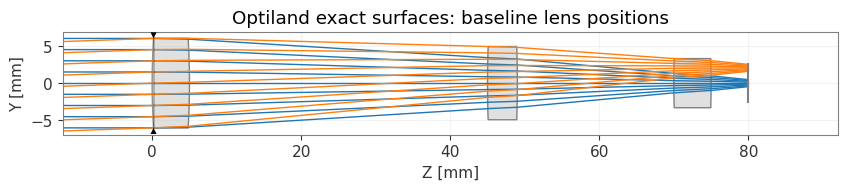

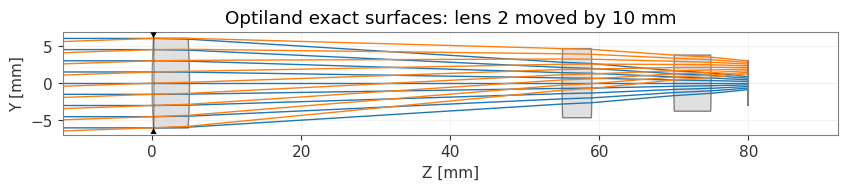

In [5]:
baseline_system.draw(num_rays=9)
plt.title('Optiland exact surfaces: baseline lens positions')
if CFG.save_figures:
    plt.gcf().savefig(FIG_DIR/'lens_group_baseline.png', dpi=180, bbox_inches='tight')
plt.show()

moved_system.draw(num_rays=9)
plt.title(f'Optiland exact surfaces: lens {CFG.moved_lens_index+1} moved by {CFG.movement_mm:g} mm')
if CFG.save_figures:
    plt.gcf().savefig(FIG_DIR/'lens_group_moved.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Fast paraxial trajectory comparison

At a thin lens, the ray angle changes by `-y/f`; between lenses, the height changes by distance times angle. This first-order model exposes the convergence shift cleanly and is useful for sweeps. Optiland above remains the exact spherical-surface calculation.

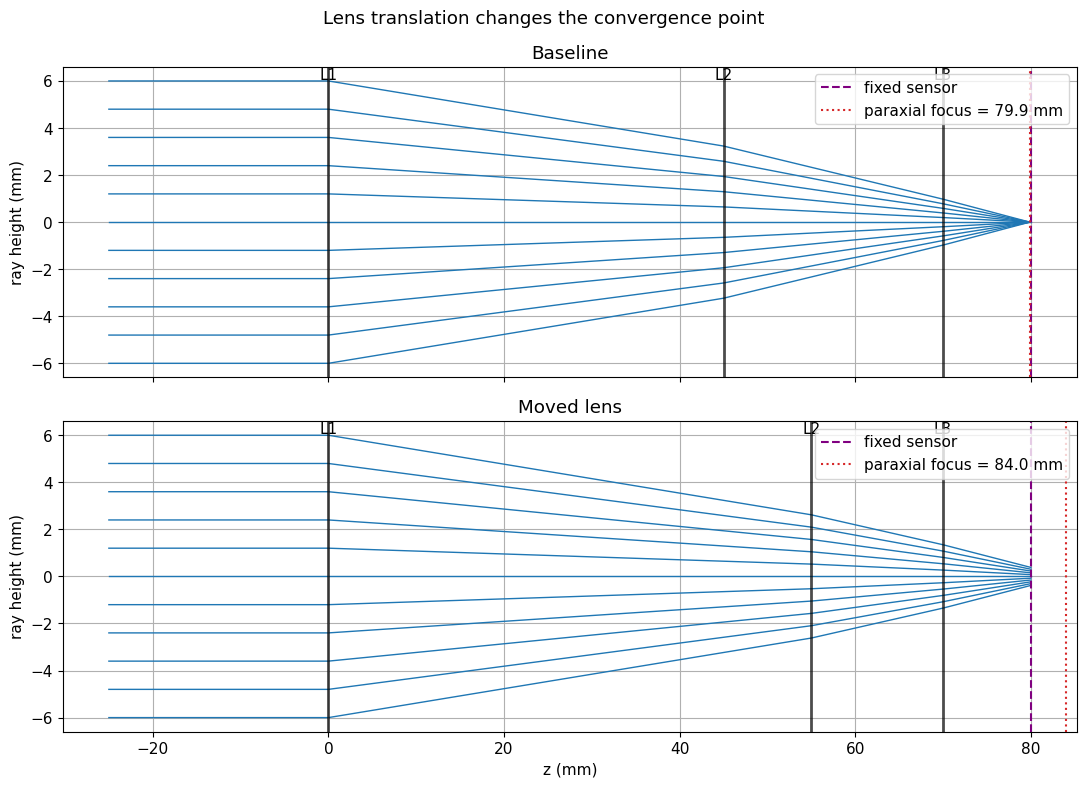

Paraxial focus: baseline 79.880 mm; moved 83.964 mm; shift +4.085 mm


In [6]:
def trace_paraxial(lenses, sensor_z, ray_heights, field_angle_deg=0.0, z_start=-25.0):
    y = np.asarray(ray_heights, dtype=float).copy()
    u = np.full_like(y, np.deg2rad(field_angle_deg))
    z_now = float(z_start)
    z_path = [z_now]
    y_path = [y.copy()]
    for lens in lenses:
        y = y + (lens.z_mm-z_now)*u
        z_now = lens.z_mm
        z_path.append(z_now); y_path.append(y.copy())
        u = u - y/lensmaker_focal_length(lens)
        z_path.append(z_now); y_path.append(y.copy())
    y = y + (sensor_z-z_now)*u
    z_path.append(sensor_z); y_path.append(y.copy())
    return np.asarray(z_path), np.asarray(y_path), y, u

def paraxial_focus(lenses):
    heights = np.array([-1.0, 1.0])
    z, path, y_last, u_last = trace_paraxial(
        lenses, lenses[-1].z_mm, heights, z_start=-25.0
    )
    focus_candidates = lenses[-1].z_mm - y_last/u_last
    return float(np.median(focus_candidates[np.isfinite(focus_candidates)]))

ray_heights = np.linspace(-CFG.aperture_diameter_mm/2, CFG.aperture_diameter_mm/2, 11)
z_b, y_b, sensor_b, _ = trace_paraxial(BASE_LENSES, CFG.sensor_z_mm, ray_heights)
z_m, y_m, sensor_m, _ = trace_paraxial(MOVED_LENSES, CFG.sensor_z_mm, ray_heights)
focus_b, focus_m = paraxial_focus(BASE_LENSES), paraxial_focus(MOVED_LENSES)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, z, paths, lenses, title, focus in (
    (axes[0], z_b, y_b, BASE_LENSES, 'Baseline', focus_b),
    (axes[1], z_m, y_m, MOVED_LENSES, 'Moved lens', focus_m),
):
    for j in range(paths.shape[1]):
        ax.plot(z, paths[:, j], color='tab:blue', lw=1)
    for lens in lenses:
        ax.axvline(lens.z_mm, color='black', lw=2, alpha=0.7)
        ax.text(lens.z_mm, 0.96, lens.name, transform=ax.get_xaxis_transform(), ha='center')
    ax.axvline(CFG.sensor_z_mm, color='purple', ls='--', label='fixed sensor')
    ax.axvline(focus, color='tab:red', ls=':', label=f'paraxial focus = {focus:.1f} mm')
    ax.set(ylabel='ray height (mm)', title=title)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('z (mm)')
fig.suptitle('Lens translation changes the convergence point')
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'lens_group_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Paraxial focus: baseline {focus_b:.3f} mm; moved {focus_m:.3f} mm; shift {focus_m-focus_b:+.3f} mm')

## 5. Optiland spot sizes and chromatic response

RMS spot radius at the fixed sensor quantifies defocus. The wavelength loop also reveals longitudinal/transverse chromatic residuals from the mixed glass group.

system,baseline,moved
wavelength_nm,,
486.100000,0.301488,0.585346
587.600000,0.341083,0.619862
656.300000,0.358316,0.635036


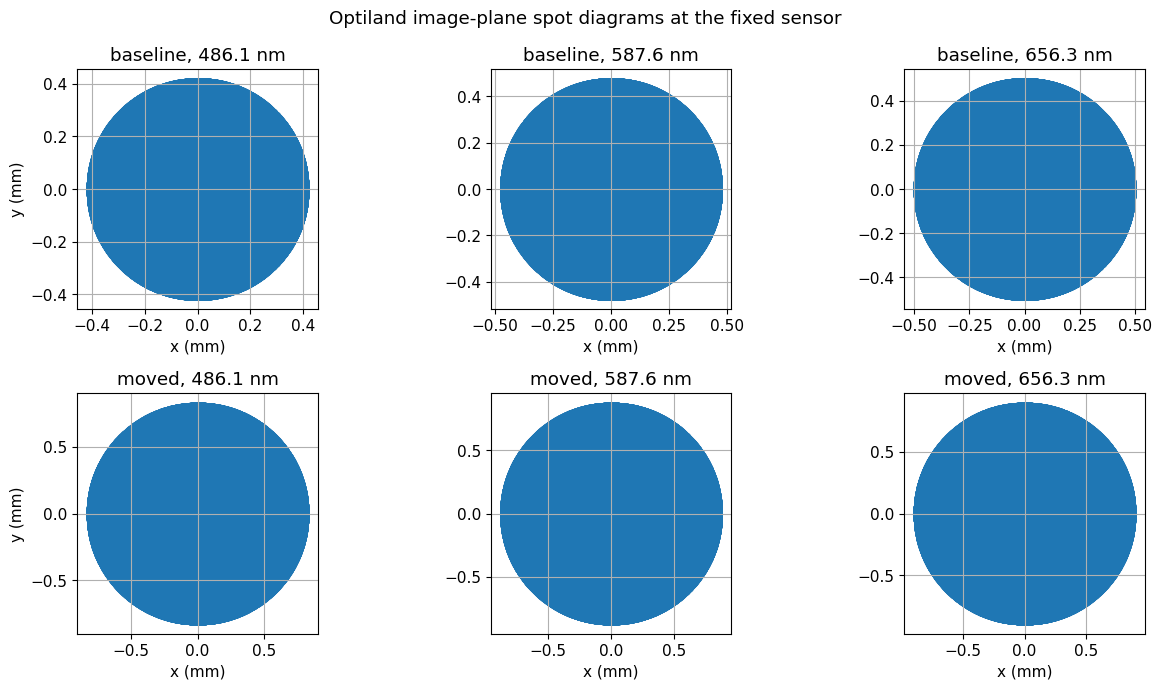

In [7]:
def rms_spot_radius(system, wavelength_nm, normalized_field_y=0.0, n_rays=None):
    # Optiland Hx/Hy are normalized field coordinates: 0 is on-axis, 1 is the largest configured field.
    if not -1.0 <= normalized_field_y <= 1.0:
        raise ValueError('normalized_field_y must lie in [-1, 1].')
    rays = system.trace(
        Hx=0.0, Hy=normalized_field_y, wavelength=wavelength_nm/1000.0,
        num_rays=n_rays or CFG.n_trace_rays, distribution='hexapolar'
    )
    x, y = np.asarray(rays.x), np.asarray(rays.y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    return float(np.sqrt(np.mean((x-x.mean())**2 + (y-y.mean())**2))), x, y

records = []
spot_data = {}
for label, system in [('baseline', baseline_system), ('moved', moved_system)]:
    for wavelength in CFG.wavelengths_nm:
        rms, x, y = rms_spot_radius(system, wavelength)
        records.append({'system': label, 'wavelength_nm': wavelength, 'rms_radius_mm': rms})
        spot_data[(label, wavelength)] = (x, y)
spot_table = pd.DataFrame(records)
display(spot_table.pivot(index='wavelength_nm', columns='system', values='rms_radius_mm')
        .style.format('{:.6f}'))

fig, axes = plt.subplots(2, len(CFG.wavelengths_nm), figsize=(13, 7), squeeze=False)
for row, label in enumerate(('baseline', 'moved')):
    for col, wavelength in enumerate(CFG.wavelengths_nm):
        x, y = spot_data[(label, wavelength)]
        axes[row, col].scatter(x, y, s=5, alpha=0.55)
        axes[row, col].set_aspect('equal', adjustable='box')
        axes[row, col].set_title(f'{label}, {wavelength:g} nm')
        axes[row, col].set_xlabel('x (mm)')
        if col == 0: axes[row, col].set_ylabel('y (mm)')
fig.suptitle('Optiland image-plane spot diagrams at the fixed sensor')
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'lens_group_spots.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Two-lens position sweep

The heat map moves lenses 2 and 3 while holding lens 1 and the sensor fixed. Dark regions correspond to a smaller paraxial RMS footprint at the sensor. White cells are geometrically invalid because lenses overlap or cross the sensor.

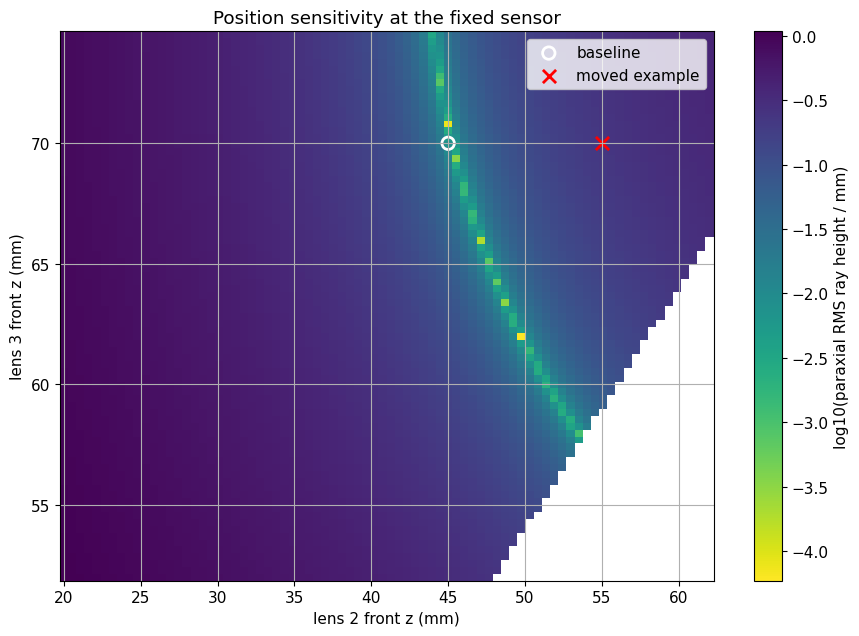

In [8]:
if len(BASE_LENSES) == 3:
    z2_values = np.linspace(20.0, 62.0, 80)
    z3_values = np.linspace(52.0, 74.5, 80)
    rms_map = np.full((len(z3_values), len(z2_values)), np.nan)
    sweep_heights = np.linspace(-CFG.aperture_diameter_mm/2, CFG.aperture_diameter_mm/2, 31)
    for row, z3 in enumerate(z3_values):
        for col, z2 in enumerate(z2_values):
            trial = (BASE_LENSES[0], replace(BASE_LENSES[1], z_mm=z2), replace(BASE_LENSES[2], z_mm=z3))
            try:
                validate_prescription(trial, CFG.sensor_z_mm)
            except ValueError:
                continue
            *_, sensor_y, _ = trace_paraxial(trial, CFG.sensor_z_mm, sweep_heights)
            rms_map[row, col] = np.sqrt(np.mean((sensor_y-sensor_y.mean())**2))

    fig, ax = plt.subplots(figsize=(9, 6.5))
    mesh = ax.pcolormesh(z2_values, z3_values, np.log10(rms_map), shading='auto', cmap='viridis_r')
    ax.scatter(BASE_LENSES[1].z_mm, BASE_LENSES[2].z_mm, marker='o', s=80,
               facecolor='none', edgecolor='white', linewidth=2, label='baseline')
    ax.scatter(MOVED_LENSES[1].z_mm, MOVED_LENSES[2].z_mm, marker='x', s=90,
               color='red', linewidth=2, label='moved example')
    ax.set(xlabel='lens 2 front z (mm)', ylabel='lens 3 front z (mm)',
           title='Position sensitivity at the fixed sensor')
    fig.colorbar(mesh, ax=ax, label='log10(paraxial RMS ray height / mm)')
    ax.legend()
    fig.tight_layout()
    if CFG.save_figures:
        fig.savefig(FIG_DIR/'lens_group_sweep.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Position heat map skipped: it requires three lenses.')

## 7. Optional interactive movement control

The widget updates the paraxial trajectories immediately. Copy a promising pair of positions into `BASE_LENSES`, rebuild the Optiland system, and rerun the spot calculation for the exact result.

In [9]:
def interactive_layout(z_lens2=BASE_LENSES[1].z_mm, z_lens3=BASE_LENSES[-1].z_mm):
    if len(BASE_LENSES) == 2:
        trial = (BASE_LENSES[0], replace(BASE_LENSES[1], z_mm=z_lens2))
    else:
        trial = (BASE_LENSES[0], replace(BASE_LENSES[1], z_mm=z_lens2),
                 replace(BASE_LENSES[2], z_mm=z_lens3))
    try:
        validate_prescription(trial, CFG.sensor_z_mm)
    except ValueError as exc:
        print(exc); return
    z, paths, sensor_y, _ = trace_paraxial(trial, CFG.sensor_z_mm, ray_heights)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(z, paths, color='tab:blue', lw=1)
    for lens in trial: ax.axvline(lens.z_mm, color='black', lw=2)
    ax.axvline(CFG.sensor_z_mm, color='purple', ls='--')
    ax.set(xlabel='z (mm)', ylabel='ray height (mm)',
           title=f'RMS height at sensor = {np.std(sensor_y):.5f} mm')
    plt.show()

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    if len(BASE_LENSES) == 3:
        interact(interactive_layout,
                 z_lens2=widgets.FloatSlider(min=10, max=64, step=1, value=BASE_LENSES[1].z_mm),
                 z_lens3=widgets.FloatSlider(min=50, max=74, step=1, value=BASE_LENSES[2].z_mm))
    else:
        interact(interactive_layout,
                 z_lens2=widgets.FloatSlider(min=10, max=74, step=1, value=BASE_LENSES[1].z_mm),
                 z_lens3=widgets.fixed(BASE_LENSES[1].z_mm))
except ImportError:
    print('ipywidgets is not installed; call interactive_layout(z_lens2=..., z_lens3=...) manually.')

interactive(children=(FloatSlider(value=45.0, description='z_lens2', max=64.0, min=10.0, step=1.0), FloatSlide…